In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv


In [2]:
import warnings
warnings.simplefilter(action='ignore', category=Warning)

# 1. First look at the data

In [3]:
df_train = pd.read_csv('/kaggle/input/playground-series-s6e1/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s6e1/test.csv')

In [4]:
df_train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
df_test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


The features are numerical and categorical:

In [6]:
df_train.info()
print('-' * 50)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27000

According to descriptive statistics, values of all features look reasonable. It's logical, because the data is synthetic:

In [11]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.000,157499.75,314999.5,472499.25,629999.00
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [12]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
id,270000.0,764999.500000,77942.430678,630000.00,697499.75,764999.50,832499.25,899999.00
age,270000.0,20.544137,2.260452,17.00,19.00,21.00,23.00,24.00
study_hours,270000.0,4.003878,2.357741,0.08,1.98,4.01,6.05,7.91
class_attendance,270000.0,71.982509,17.414695,40.60,57.00,72.60,87.20,99.40
sleep_hours,270000.0,7.072070,1.745513,4.10,5.60,7.10,8.60,9.90


The data contains no NAN values:

In [13]:
df_train.isnull().sum().sum(), df_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

The data contains no duplicates:

In [14]:
df_train.duplicated().sum(), df_test.duplicated().sum()

(np.int64(0), np.int64(0))

# 2. EDA and primary data processing

Obviously, 'id' column is useless, but we'll keep it for df_test (it will be useful for our submission file):

In [4]:
df_train = df_train.drop(columns='id')

idx_submission = df_test['id']
df_test = df_test.drop(columns='id')

Let's take a look on target variable distribution. It looks almost normal (except border values):

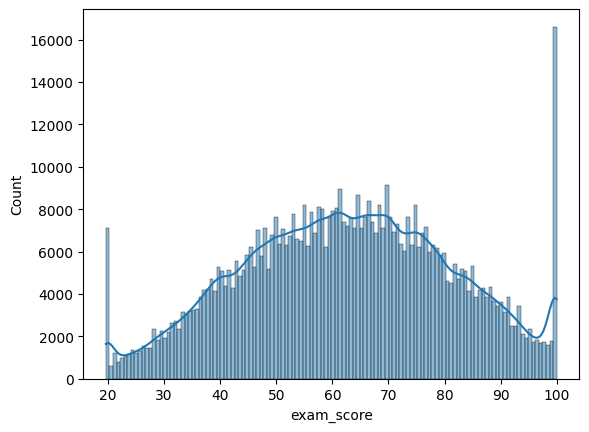

In [17]:
sns.histplot(df_train['exam_score'], kde=True);

**2.1 Categorical features**

Let's choose categorical features:

In [5]:
cat_features = df_train.select_dtypes(include='object').columns.tolist()
df_train_cat = df_train.select_dtypes(include='object')
df_test_cat = df_test.select_dtypes(include='object')

cat_features

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [19]:
df_train_cat.head()

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
0,female,b.sc,no,average,online videos,low,easy
1,other,diploma,yes,poor,self-study,medium,moderate
2,female,b.sc,yes,poor,coaching,high,moderate
3,male,b.sc,yes,average,group study,high,moderate
4,male,bca,yes,good,self-study,high,easy


Let's plot graphs for categorical features. We need to add target variable:

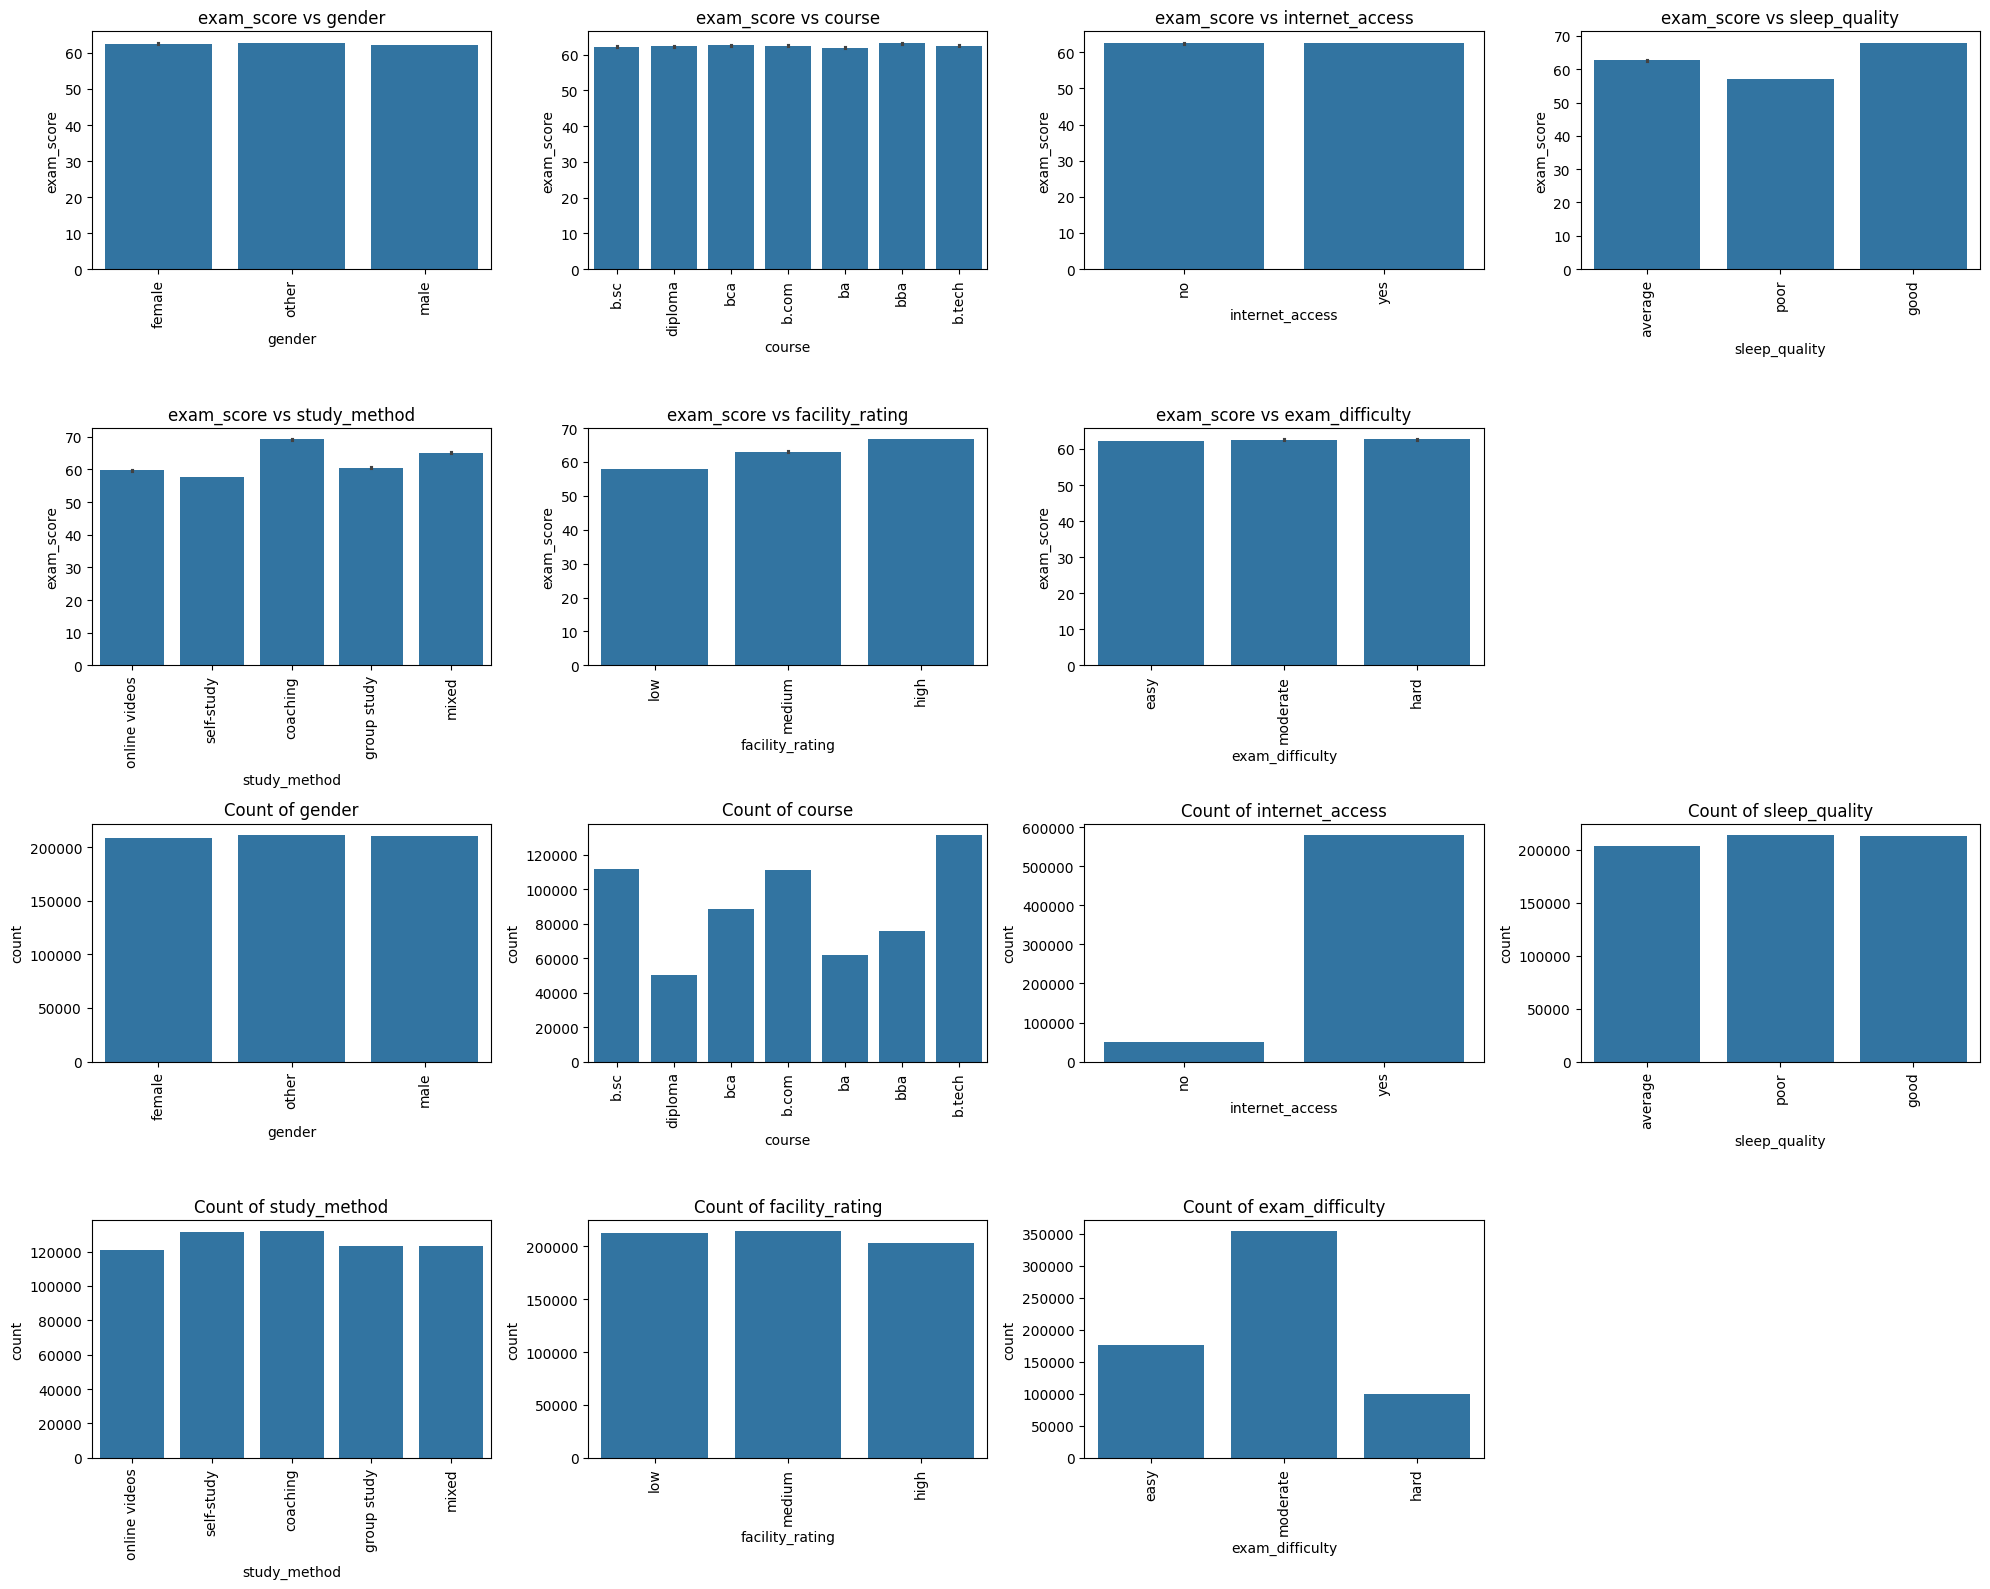

In [20]:
df_train_cat_target = df_train_cat.join(df_train['exam_score'])

def cat_features_vis(df):
    fig, ax = plt.subplots(4, 4, figsize=(20, 16))
    ax = ax.flatten()

    for i, col in enumerate(df.drop(columns='exam_score').columns):
        p = sns.barplot(x=df[col], y=df['exam_score'], ax=ax[i], estimator='mean');
        p.set_xticklabels(p.get_xticklabels(), rotation=90); # turning ticks of axis for ax
        ax[i].set_title(f'exam_score vs {col}')
        
        g = sns.countplot(x=df[col], ax=ax[i + 8]);
        g.set_xticklabels(g.get_xticklabels(), rotation=90); # turning ticks of axis for ax
        ax[i + 8].set_title(f'Count of {col}')
        
    # let's hide excess axis
    ax[7].set_visible(False)
    ax[-1].set_visible(False)
    plt.tight_layout()


cat_features_vis(df_train_cat_target)

We have values 'other' in 'gender' column, it's weird. Maybe, it's NaN?

In [21]:
df_train['gender'].value_counts()

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [22]:
df_test['gender'].value_counts()

gender
male      90682
other     90111
female    89207
Name: count, dtype: int64

Quantity of 'other' values in 'gender' is big in train and test, so we'll leave it like now.

Plots show that 'exam score' for different genders remained virtually unchanged (like for a lot of other features), let's check it:

In [23]:
df_train.groupby('gender').agg({'exam_score': 'mean'})

,exam_score
gender,
female,62.563220
male,62.175561
other,62.781191


Let's create a Series with unique values of all categorical features:

In [24]:
unique_values = pd.Series(index=cat_features, name='unique_values')
for i, col in enumerate(df_train_cat.columns):
    unique_values[i] = df_train_cat[col].unique().tolist()

unique_values

gender                                         [female, other, male]
course                  [b.sc, diploma, bca, b.com, ba, bba, b.tech]
internet_access                                            [no, yes]
sleep_quality                                  [average, poor, good]
study_method       [online videos, self-study, coaching, group st...
facility_rating                                  [low, medium, high]
exam_difficulty                               [easy, moderate, hard]
Name: unique_values, dtype: object


**Generally, we can draw a conclusion that categorical features don't impact on target variable strongly. Also our data has low cardinality.**

**We can apply OrdinalEncoder for features 'sleep_quality' and 'facility_rating', because they are ordinal and plots show that target depends on them.**


**2.2 Numerical features**

Let's choose numerical features:

In [6]:
num_features = df_train.select_dtypes(include='number').columns.tolist()
df_train_num = df_train.select_dtypes(include='number')
df_test_num = df_test.select_dtypes(include='number')

num_features

['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

In [26]:
df_train_num.head()

,age,study_hours,class_attendance,sleep_hours,exam_score
0,21,7.91,98.8,4.9,78.3
1,18,4.95,94.8,4.7,46.7
2,20,4.68,92.6,5.8,99.0
3,19,2.00,49.5,8.3,63.9
4,23,7.65,86.9,9.6,100.0


Let's estimate correlation between numerical features:

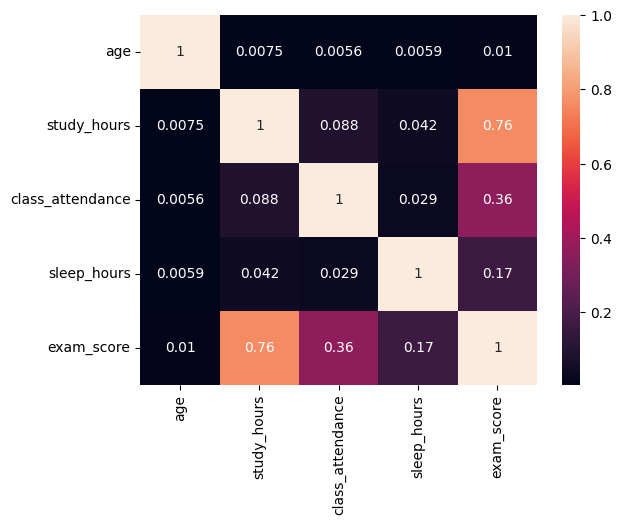

In [27]:
sns.heatmap(df_train_num.corr(), annot=True);

Let's plot graphs for numerical features.

Please note that our data is huge (630000 entries in df_train), so we'll take a sample to make sense to graphs (especially scatterplots):

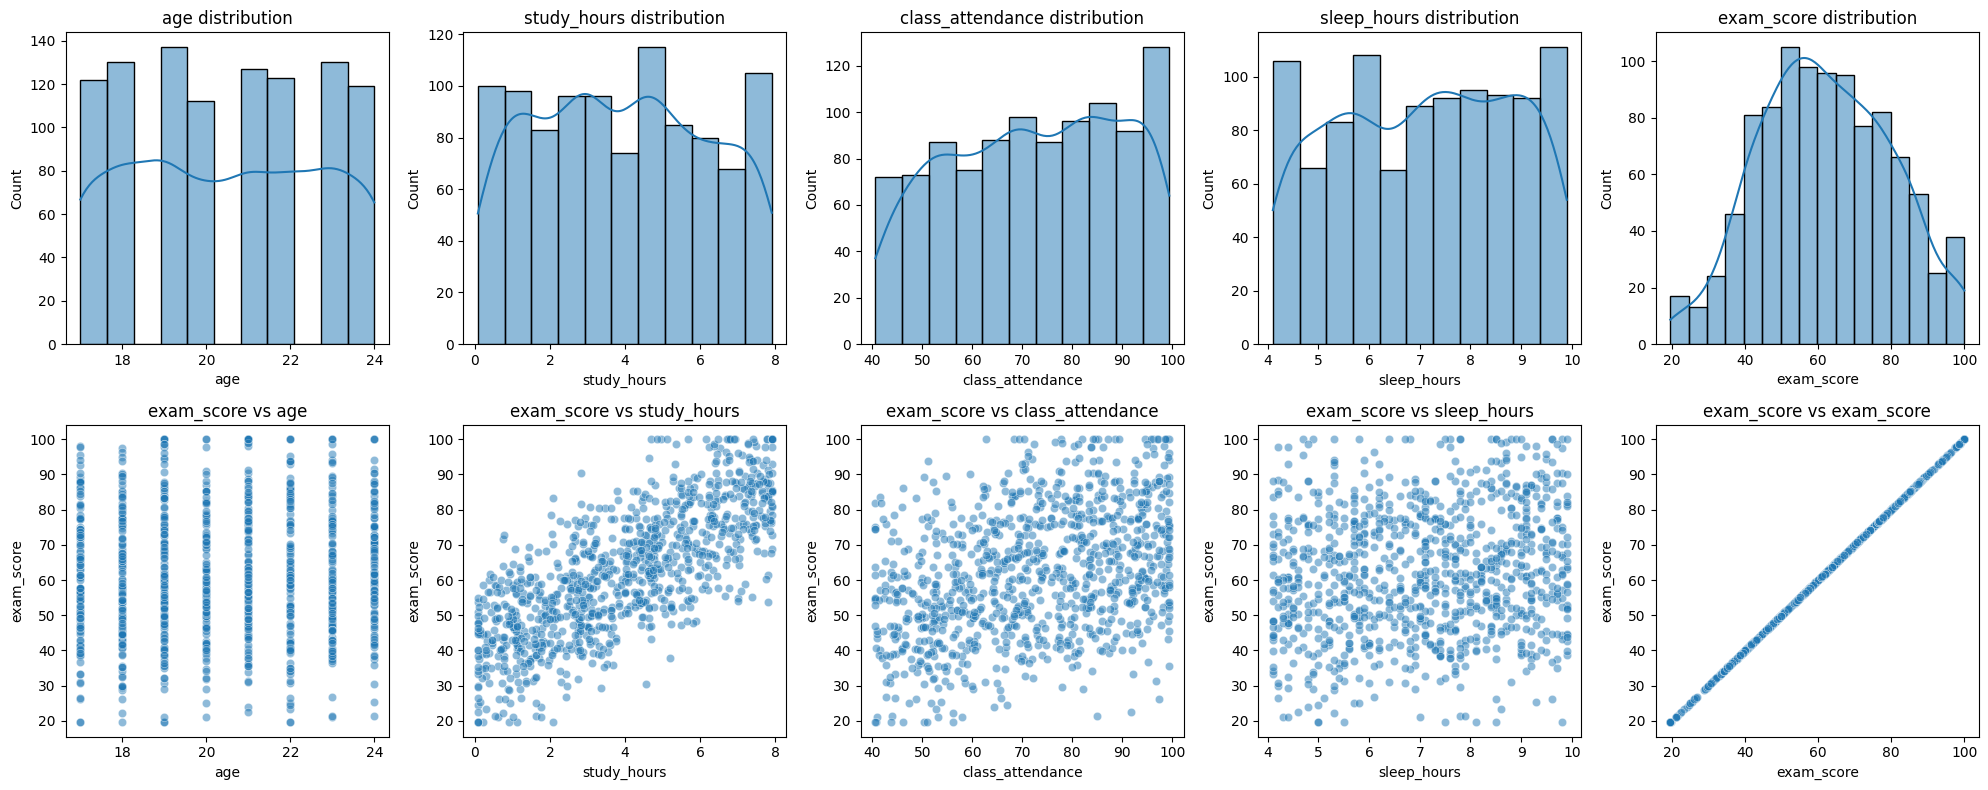

In [28]:
def num_features_vis(df):
    # we're taking sample in df_train
    df = df.sample(1000, replace=False)

    fig, ax = plt.subplots(2, 5, figsize=(20, 8))
    ax = ax.flatten()

    for i, col in enumerate(df.columns):
        sns.histplot(df[col], kde=True, ax=ax[i]);
        ax[i].set_title(f'{col} distribution')
        
        sns.scatterplot(x=df[col], y=df['exam_score'], alpha=0.5, ax=ax[i + 5]);
        ax[i + 5].set_title(f'exam_score vs {col}')

    plt.tight_layout()


num_features_vis(df_train_num)

We also can make pairplot graphs:

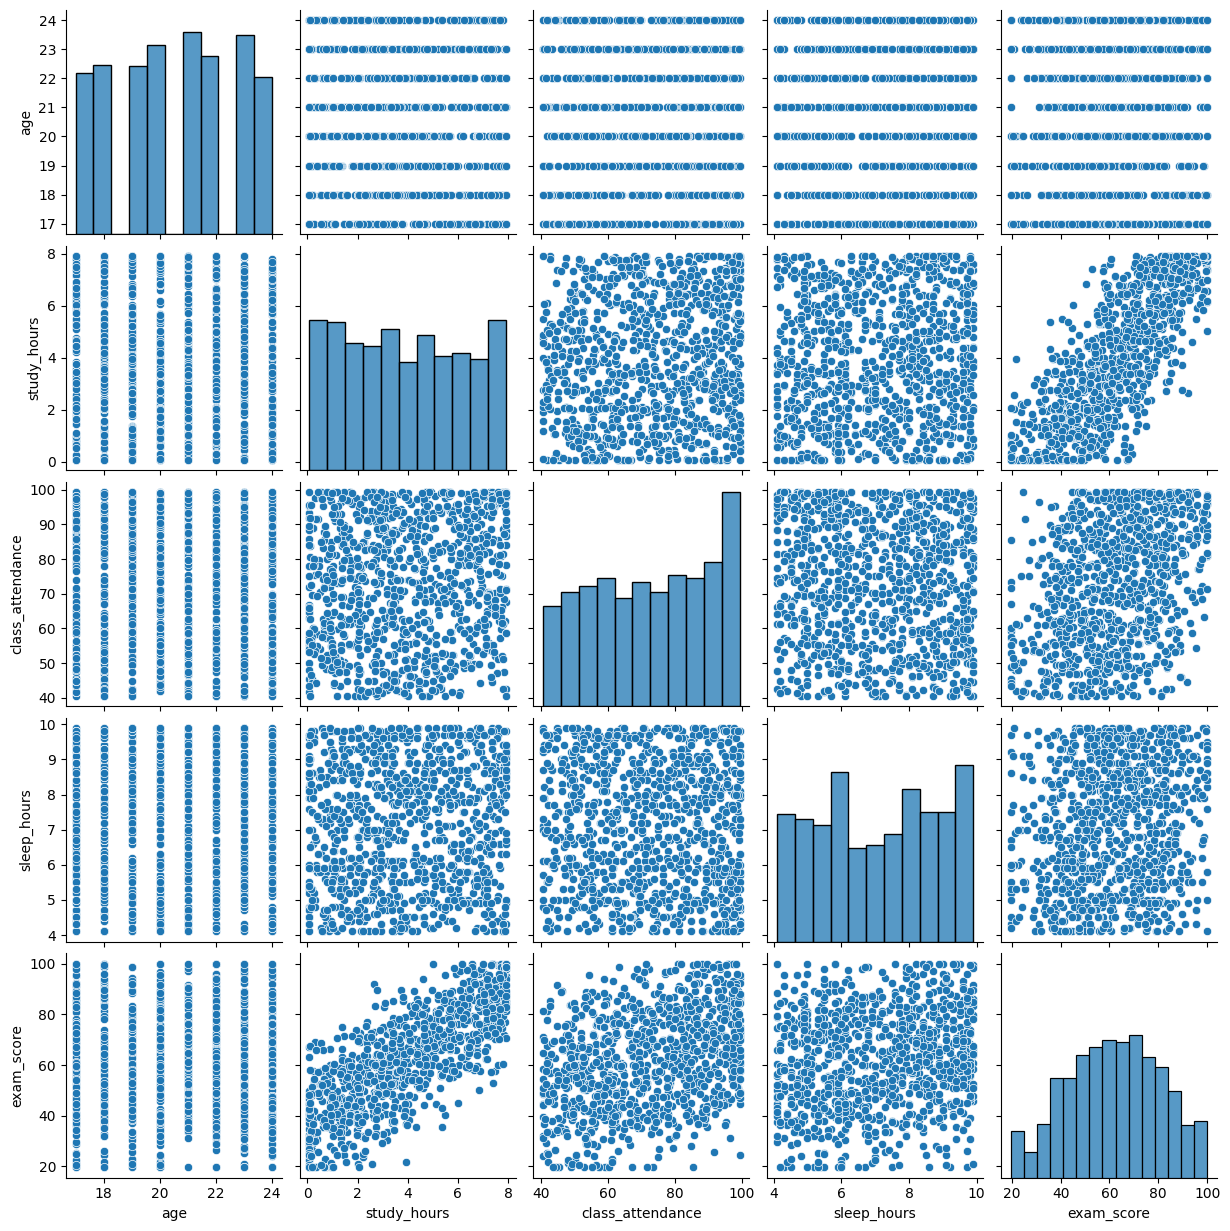

In [29]:
df_train_num_sample = df_train_num.sample(1000, replace=False)
sns.pairplot(df_train_num_sample);

And we can make boxplot graphs for relation between numerical and categorical features and for outliers detection:

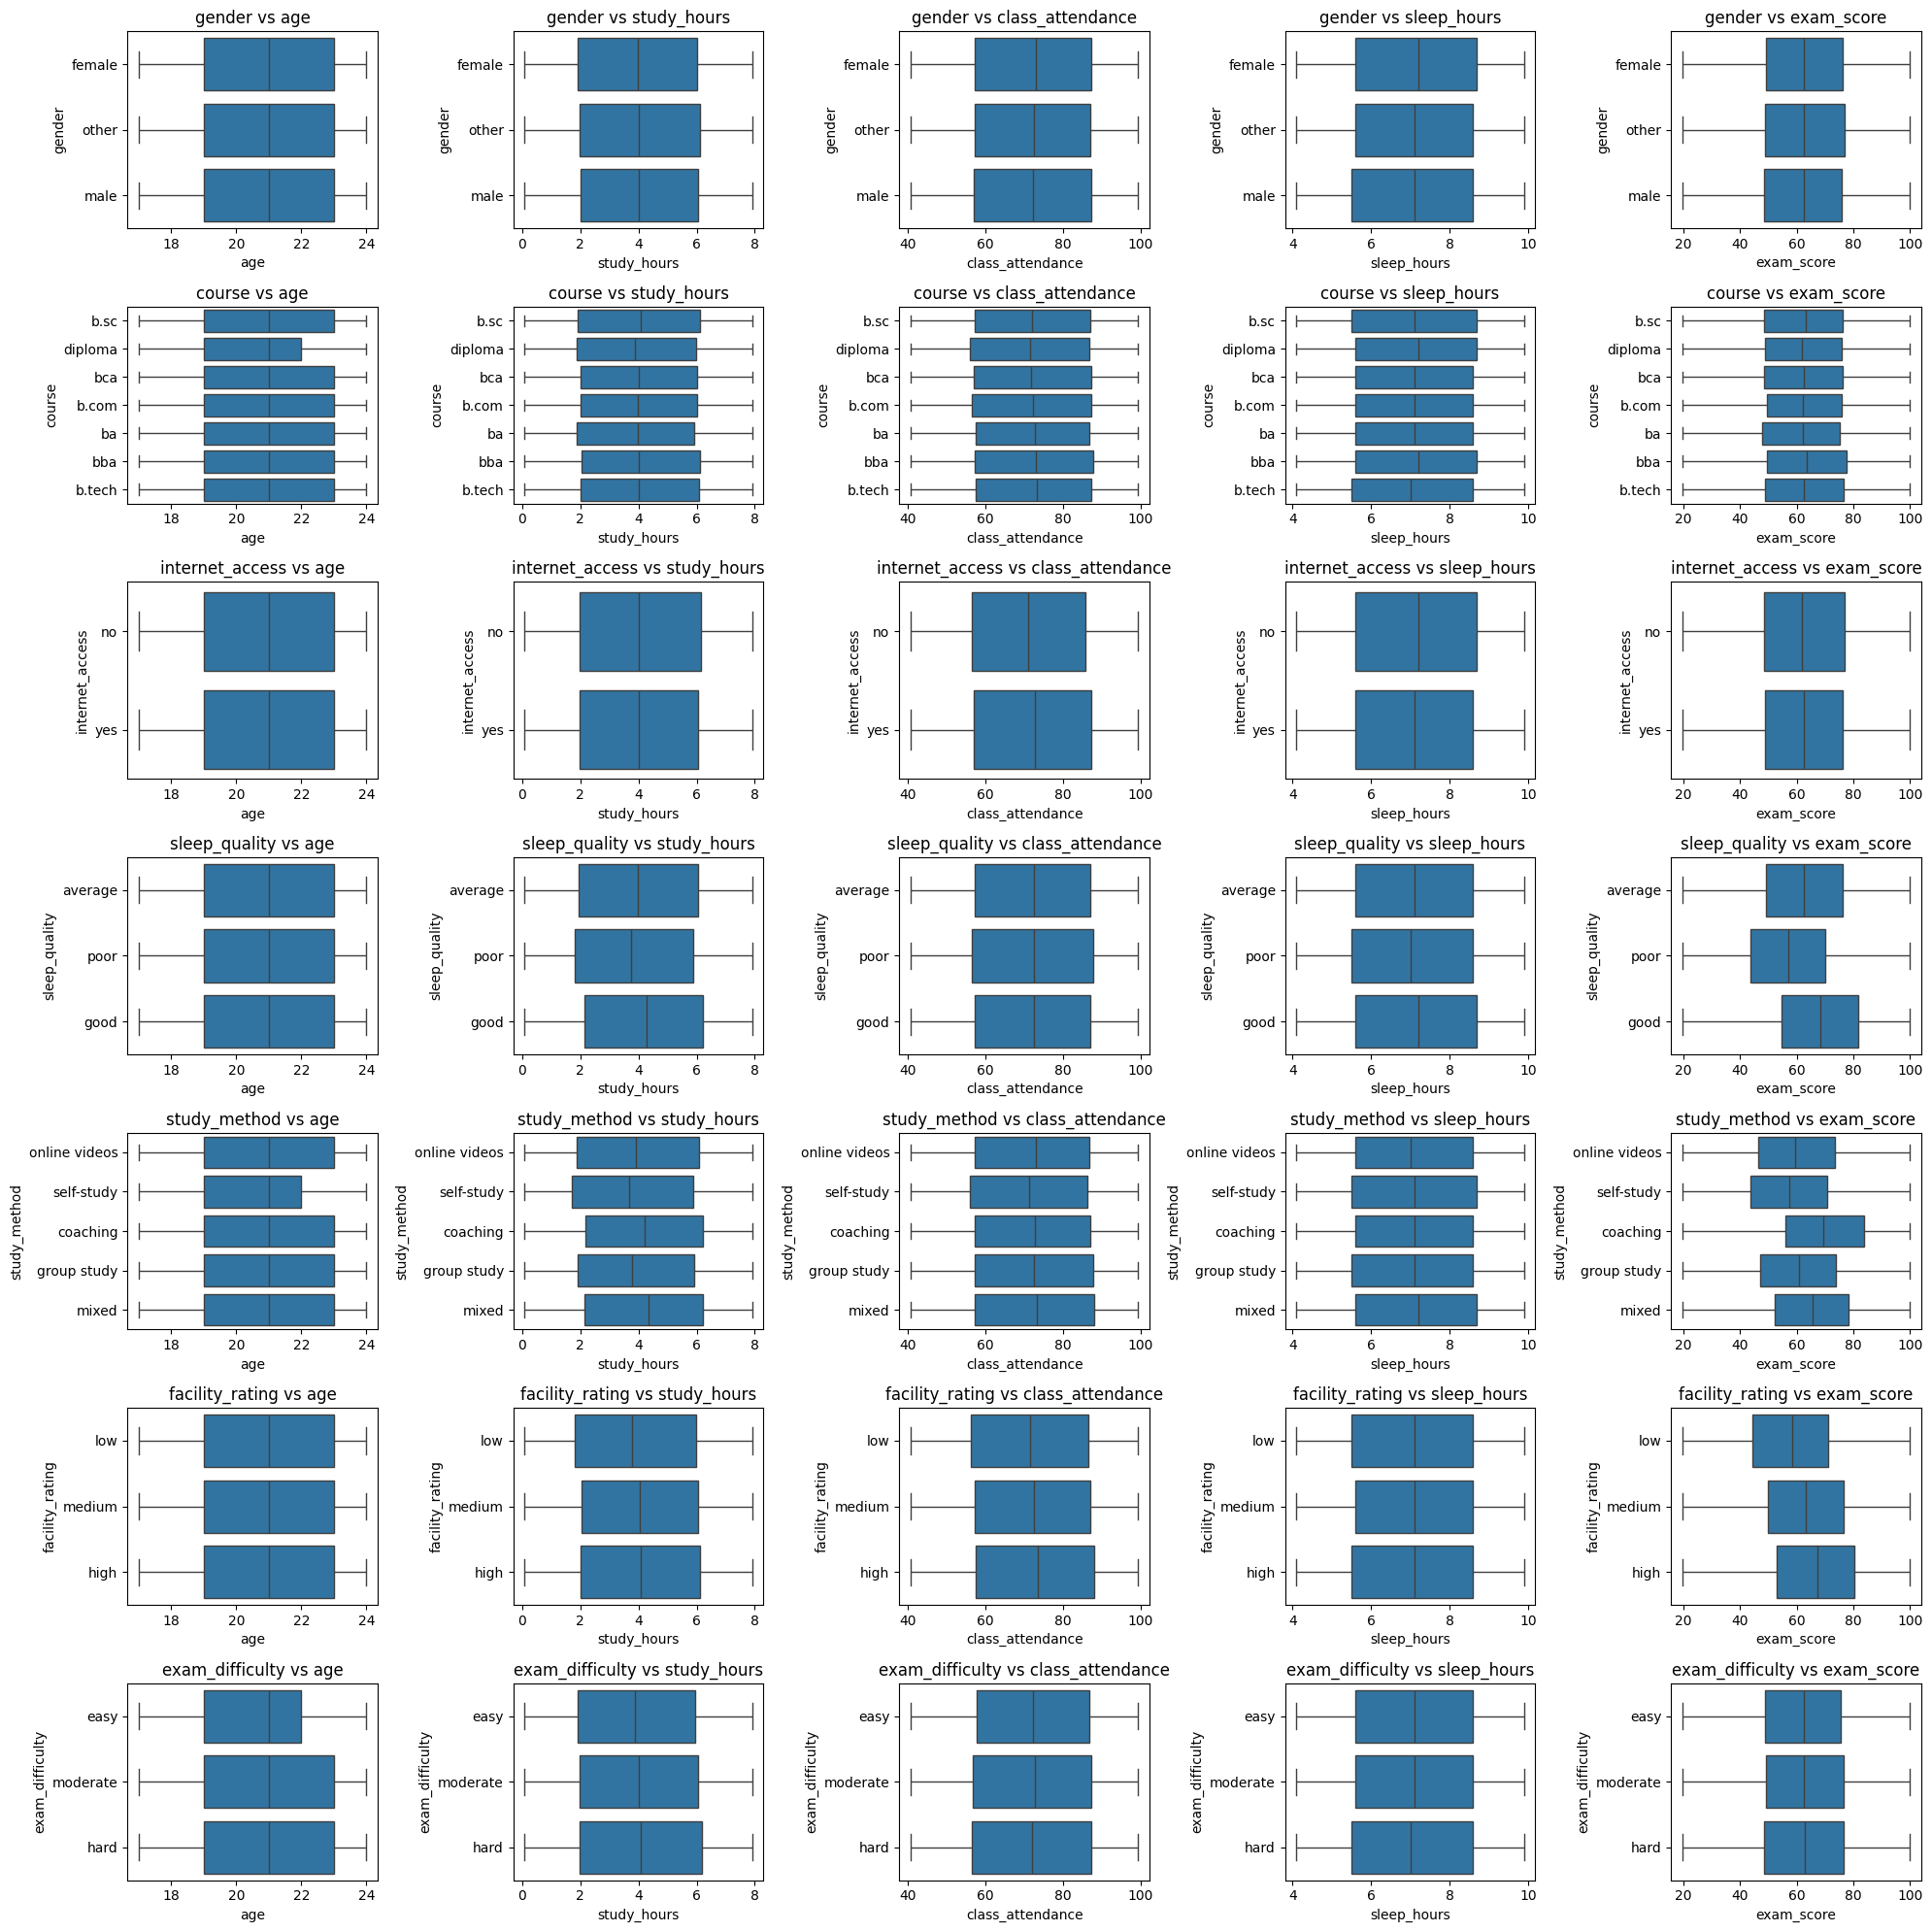

In [30]:
def outliers_vis(df):
    fig, ax = plt.subplots(7, 5, figsize=(20, 20))

    for i, col_cat in enumerate(df_train_cat.columns):
        for j, col_num in enumerate(df.columns):
            sns.boxplot(x=df[col_num], y=df_train[col_cat], ax=ax[i, j])
            ax[i, j].set_title(f'{col_cat} vs {col_num}')

    plt.tight_layout()


outliers_vis(df_train_num)

Boxplots show that data doesn't contain outliers. We will consider this issue in more detail in chapter 4.

**Takeaways**

**We have few features, all they will be used. We can create a new features also.**

# 3. Baseline

To get a preliminary estimation, we'll use a base model without data preprocessing. We can do it, because models of gradient boosting (based on trees) can process categorical features and they don't need scaling of data.

Let's divide our data to features (X) and target variable (y).

In [7]:
X_train = df_train.drop(columns='exam_score')
y_train = df_train['exam_score']
X_test = df_test

y_train.head()

0     78.3
1     46.7
2     99.0
3     63.9
4    100.0
Name: exam_score, dtype: float64

In [31]:
from catboost import CatBoostRegressor

# we need to specify categorical features in parameters
base_model = CatBoostRegressor(cat_features=cat_features, verbose=False)
base_model.fit(X_train, y_train)
base_model_pred = base_model.predict(X_test)

In [32]:
result = pd.DataFrame({'id': idx_submission, 'exam_score': base_model_pred})
submission_base_model = result.to_csv('submission_base_model.csv', index=False)
print('✅ submission_base_model.csv created successfully!')

# score 8.73705

✅ submission_base_model.csv created successfully!


# 4. Data preprocessing

**4.1 Missing values**

The data contains no missing values.

**4.2 Categorical features encoding**

Although gradient boosting can work with categorical features, we'll encode them in our own way. As mentioned above, we can apply OrdinalEncoder for ordinal features.

In [8]:
ord_features = ['sleep_quality', 'facility_rating']
other_cat_features = list(set(cat_features) - set(ord_features))

other_cat_features

['gender', 'internet_access', 'exam_difficulty', 'course', 'study_method']

In [9]:
# values 1, 2, 3 for encoding may be clarified
X_train['sleep_quality_enc'] = X_train['sleep_quality'].map({'poor': 1, 'average': 2, 'good': 3})
X_train['facility_rating_enc'] = X_train['facility_rating'].map({'low': 1, 'medium': 2, 'high': 3})

X_test['sleep_quality_enc'] = X_test['sleep_quality'].map({'poor': 1, 'average': 2, 'good': 3})
X_test['facility_rating_enc'] = X_test['facility_rating'].map({'low': 1, 'medium': 2, 'high': 3})

X_train = X_train.drop(columns=ord_features)
X_test = X_test.drop(columns=ord_features)

In [12]:
X_train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,study_method,exam_difficulty,sleep_quality_enc,facility_rating_enc
0,21,female,b.sc,7.91,98.8,no,4.9,online videos,easy,2,1
1,18,other,diploma,4.95,94.8,yes,4.7,self-study,moderate,1,2
2,20,female,b.sc,4.68,92.6,yes,5.8,coaching,moderate,1,3
3,19,male,b.sc,2.00,49.5,yes,8.3,group study,moderate,2,3
4,23,male,bca,7.65,86.9,yes,9.6,self-study,easy,3,3


In [61]:
X_test.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,study_method,exam_difficulty,sleep_quality_enc,facility_rating_enc
0,24,other,ba,6.85,65.2,yes,5.2,group study,easy,1,3
1,18,male,diploma,6.61,45.0,no,9.3,coaching,easy,1,1
2,24,female,b.tech,6.60,98.5,yes,6.2,group study,moderate,3,2
3,24,male,diploma,3.03,66.3,yes,5.7,mixed,moderate,2,2
4,20,female,b.tech,2.03,42.4,yes,9.2,coaching,moderate,2,1


To encode the remaining features, we will use OneHotEncoder.

In [10]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_encoded = pd.DataFrame(ohe.fit_transform(X_train[other_cat_features]), columns=ohe.get_feature_names_out())
X_train = X_train.drop(columns=other_cat_features).join(X_train_encoded)

X_test_encoded = pd.DataFrame(ohe.transform(X_test[other_cat_features]), columns=ohe.get_feature_names_out())
X_test = X_test.drop(columns=other_cat_features).join(X_test_encoded)

In [11]:
X_train.head()

,age,study_hours,class_attendance,sleep_hours,sleep_quality_enc,facility_rating_enc,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,...,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,21,7.91,98.8,4.9,2,1,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,18,4.95,94.8,4.7,1,2,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,20,4.68,92.6,5.8,1,3,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19,2.00,49.5,8.3,2,3,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,23,7.65,86.9,9.6,3,3,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [12]:
X_test.head()

,age,study_hours,class_attendance,sleep_hours,sleep_quality_enc,facility_rating_enc,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,...,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,24,6.85,65.2,5.2,1,3,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,18,6.61,45.0,9.3,1,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,24,6.60,98.5,6.2,3,2,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,24,3.03,66.3,5.7,2,2,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,20,2.03,42.4,9.2,2,1,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**4.3 Work with outliers**

Let's estimate quantity of outliers with interquartile range (IQR):

In [16]:
def outlier_count(df):
    Q25, Q75 = df.quantile(0.25, axis=0), df.quantile(0.75, axis=0)
    IQR = Q75 - Q25
    lower_bound, upper_bound = Q25 - 1.5 * IQR, Q75 + 1.5 * IQR
    # fraction of outliers of each feature in percents
    quantity = ((df <= lower_bound) | (df >= upper_bound)).sum(axis=0) / df.shape[0] * 100
    return quantity.sort_values(ascending=False)


outlier_count(df_train_num)

age                 0.0
study_hours         0.0
class_attendance    0.0
sleep_hours         0.0
exam_score          0.0
dtype: float64

The data contains no outliers, if we believe in IQR method. It fits with boxplots we made before.

We also can use Isolation Forest to detect outliers:

In [13]:
# we're removing target variable from num_features
num_features_without_target = list(set(num_features) - set(['exam_score']))
X_train_num = X_train[num_features_without_target]
X_test_num = X_test[num_features_without_target]

In [68]:
from sklearn.ensemble import IsolationForest

isof = IsolationForest(n_estimators=100, max_samples=10000, random_state=42, n_jobs=-1)
isof_pred = isof.fit_predict(X_train_num) # labels
isof_anomaly_score = isof.decision_function(X_train_num) # anomaly score

isof_pred

array([-1, -1,  1, ..., -1,  1,  1])

In [69]:
# quantity of outliers (label -1 means it's an outlier)
X_train_num[isof_pred == -1].shape[0]

462336

Prediction using the Isolation Forest algorithm shows that many objects are outliers. This may be due to the fact that our data is synthetic.

**4.4 Feature engineering**

We can try to create a new feature, for example, 'work_and_relax' - product of 'study_hours', 'class_attendance' and'sleep_hours'. It can makes sense, because 'exam_score' has positive correlation with all of them.

Addition of new feature is not necessarily, we can comment out cells below.

In [14]:
X_train['work_and_relax'] = X_train['study_hours'] * X_train['class_attendance'] * X_train['sleep_hours']
X_test['work_and_relax'] = X_test['study_hours'] * X_test['class_attendance'] * X_test['sleep_hours']

In [15]:
X_train['sleep_level'] = X_train['sleep_hours'] * X_train['sleep_quality_enc']
X_test['sleep_level'] = X_test['sleep_hours'] * X_test['sleep_quality_enc']

In [16]:
X_train.head()

,age,study_hours,class_attendance,sleep_hours,sleep_quality_enc,facility_rating_enc,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,...,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,work_and_relax,sleep_level
0,21,7.91,98.8,4.9,2,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3829.3892,9.8
1,18,4.95,94.8,4.7,1,2,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2205.5220,4.7
2,20,4.68,92.6,5.8,1,3,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2513.5344,5.8
3,19,2.00,49.5,8.3,2,3,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,821.7000,16.6
4,23,7.65,86.9,9.6,3,3,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6381.9360,28.8


In [17]:
X_test.head()

,age,study_hours,class_attendance,sleep_hours,sleep_quality_enc,facility_rating_enc,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,...,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,work_and_relax,sleep_level
0,24,6.85,65.2,5.2,1,3,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2322.4240,5.2
1,18,6.61,45.0,9.3,1,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2766.2850,9.3
2,24,6.60,98.5,6.2,3,2,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4030.6200,18.6
3,24,3.03,66.3,5.7,2,2,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1145.0673,11.4
4,20,2.03,42.4,9.2,2,1,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,791.8624,18.4


In [18]:
new_features = ['work_and_relax', 'sleep_level']

**4.5 Scaling of numerical features**

Gradient boosting models don't require scaling, because they only work with one feature at a time. However, scaling is a good practice and it can be useful for other models.

We should encode ordinal features and new features too.

In [19]:
num_features_for_encoding = num_features_without_target + ['sleep_quality_enc', 'facility_rating_enc'] + new_features
num_features_for_encoding

['sleep_hours',
 'age',
 'study_hours',
 'class_attendance',
 'sleep_quality_enc',
 'facility_rating_enc',
 'work_and_relax',
 'sleep_level']

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train[num_features_for_encoding]), columns=num_features_for_encoding)
X_train_scaled = X_train.drop(columns=num_features_for_encoding).join(X_train_num_scaled)

X_test_num_scaled = pd.DataFrame(scaler.transform(X_test[num_features_for_encoding]), columns=num_features_for_encoding)
X_test_scaled = X_test.drop(columns=num_features_for_encoding).join(X_test_num_scaled)

In [21]:
X_train_scaled.head()

,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,exam_difficulty_moderate,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,...,study_method_online videos,study_method_self-study,sleep_hours,age,study_hours,class_attendance,sleep_quality_enc,facility_rating_enc,work_and_relax,sleep_level
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,-1.245269,0.200943,1.655875,1.538302,0.001130,-1.213656,1.147458,-0.624446
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,-1.359895,-1.126352,0.401573,1.308814,-1.213871,0.017268,0.082857,-1.352275
2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-0.729454,-0.241488,0.287160,1.182595,-1.213871,1.248192,0.284788,-1.195292
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.703367,-0.683920,-0.848492,-1.290141,0.001130,1.248192,-0.824371,0.345993
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.448434,1.085807,1.545699,0.855575,1.216131,1.248192,2.820897,2.087074


In [22]:
X_test_scaled.head()

,gender_male,gender_other,internet_access_yes,exam_difficulty_hard,exam_difficulty_moderate,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,...,study_method_online videos,study_method_self-study,sleep_hours,age,study_hours,class_attendance,sleep_quality_enc,facility_rating_enc,work_and_relax,sleep_level
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,-1.073331,1.528239,1.206699,-0.389399,-1.213871,1.248192,0.159497,-1.280919
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.276496,-1.126352,1.104999,-1.548315,-1.213871,-1.213656,0.450491,-0.695802
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,-0.500202,1.528239,1.100761,1.521091,1.216131,0.017268,1.279384,0.631416
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-0.786767,1.528239,-0.412029,-0.326290,0.001130,0.017268,-0.612373,-0.396107
4,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.219183,-0.241488,-0.835779,-1.697482,0.001130,-1.213656,-0.843933,0.602874


Let's check mean and std:

In [23]:
X_train_num_scaled.mean().mean(), X_train_num_scaled.std().mean(), X_test_num_scaled.mean().mean(), X_test_num_scaled.std().mean()

(np.float64(4.3490572695176645e-16),
 np.float64(1.0000007936523159),
 np.float64(-2.9583702673045636e-06),
 np.float64(1.000326987284508))

**4.6 Final checking of data**

In [24]:
X_train_scaled.info()
print('-' * 50)
X_test_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   gender_male                 630000 non-null  float64
 1   gender_other                630000 non-null  float64
 2   internet_access_yes         630000 non-null  float64
 3   exam_difficulty_hard        630000 non-null  float64
 4   exam_difficulty_moderate    630000 non-null  float64
 5   course_b.sc                 630000 non-null  float64
 6   course_b.tech               630000 non-null  float64
 7   course_ba                   630000 non-null  float64
 8   course_bba                  630000 non-null  float64
 9   course_bca                  630000 non-null  float64
 10  course_diploma              630000 non-null  float64
 11  study_method_group study    630000 non-null  float64
 12  study_method_mixed          630000 non-null  float64
 13  study_method_o

We can convert columns to float32 format to speed up dataframes:

In [25]:
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

In [26]:
X_train_scaled.info()
print('-' * 50)
X_test_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   gender_male                 630000 non-null  float32
 1   gender_other                630000 non-null  float32
 2   internet_access_yes         630000 non-null  float32
 3   exam_difficulty_hard        630000 non-null  float32
 4   exam_difficulty_moderate    630000 non-null  float32
 5   course_b.sc                 630000 non-null  float32
 6   course_b.tech               630000 non-null  float32
 7   course_ba                   630000 non-null  float32
 8   course_bba                  630000 non-null  float32
 9   course_bca                  630000 non-null  float32
 10  course_diploma              630000 non-null  float32
 11  study_method_group study    630000 non-null  float32
 12  study_method_mixed          630000 non-null  float32
 13  study_method_o

In [27]:
X_train_scaled.isnull().sum().sum(), X_test_scaled.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [28]:
X_train_scaled.duplicated().sum(), X_test_scaled.duplicated().sum()

(np.int64(0), np.int64(0))

Our data is ready for ML.

# 5. ML and scoring

We will use different gradient boosting models with hyperparameter tuning using Optuna.

In the competition submissions are evaluated using the RMSE, so we will use this metric during hyperparameter tuning.

**5.1 XGBoost**

In [ ]:
import optuna
# from optuna.integration import XGBoostPruningCallback
from sklearn.model_selection import KFold
import xgboost as xgb
from xgboost import XGBRegressor
import time

def objective(trial, X, y):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'n_estimators': 10000, # we specify a large number of trees because we use early_stopping_rounds
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01),
        'verbosity': 0,
        'tree_method': 'hist', # we use a faster method for constructing trees
        'n_jobs': -1,
#       'gamma': trial.suggest_float('gamma', 0, 0.5, step=0.1),
#       'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#       'subsample': trial.suggest_float('subsample', 0.6, 0.9, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.4, 2, step=0.2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.4, 2, step=0.2),
        'seed': 42
             }

    # way 1 - training using KFold
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    # for saving best scores
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
        # datasets for XGBoost
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)

        # teaching with early_stopping (Optuna pruning doesn't work with this version - can't solve it)
        # pruning_callback = XGBoostPruningCallback(trial, 'validation-rmse')
        bst = xgb.train(params, dtrain, evals=[(dval, 'validation')], num_boost_round=params['n_estimators'], 
                        verbose_eval=False, early_stopping_rounds=50)
                        # callbacks=[pruning_callback]

        # getting best scores on validation (the default metric - RMSE)
        score = bst.best_score
        scores.append(score)

    # returning the average value over folds
    return np.mean(scores)

    # way 2 - training using XGB's built-in cross-validation (very long)
    # dtrain = xgb.DMatrix(X, label=y)
    # cv_results = xgb.cv(params, dtrain, num_boost_round=params['n_estimators'],
    #                     early_stopping_rounds=50, nfold=4, stratified=False,
    #                     seed=42, verbose_eval=False)

    # # returning the best RMSE value
    # return cv_results['test-rmse-mean'].mean()


study = optuna.create_study(direction='minimize', study_name='XGBoost')

# measuring the execution time
start = time.time()
study.optimize(lambda trial: objective(trial, X_train_scaled, y_train), n_trials=50, 
               n_jobs=-1, show_progress_bar=True)
end = time.time()

xgboost_optuna_score = study.best_value
xgboost_optuna_params = study.best_params

print(f'Execution time: {end - start}')

In [30]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# best hyperparameters that found using Optuna:
best_params = {'max_depth': 6, 'learning_rate': 0.02, 'subsample': 0.8,
               'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 0.9}

# we use early_stopping_rounds and validation sampling
xgbst = XGBRegressor(**best_params, n_estimators=10000, early_stopping_rounds=50)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.1)
# we can see the metric in the validation dataset every 100 iterations
xgbst.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-rmse:18.65504
[100]	validation_0-rmse:9.59552
[200]	validation_0-rmse:8.94925
[300]	validation_0-rmse:8.85157
[400]	validation_0-rmse:8.82893
[500]	validation_0-rmse:8.81686
[600]	validation_0-rmse:8.80810
[700]	validation_0-rmse:8.80022
[800]	validation_0-rmse:8.79351
[900]	validation_0-rmse:8.78804
[1000]	validation_0-rmse:8.78268
[1100]	validation_0-rmse:8.77854
[1200]	validation_0-rmse:8.77488
[1300]	validation_0-rmse:8.77195
[1400]	validation_0-rmse:8.76935
[1500]	validation_0-rmse:8.76691
[1600]	validation_0-rmse:8.76478
[1700]	validation_0-rmse:8.76282
[1800]	validation_0-rmse:8.76123
[1900]	validation_0-rmse:8.75977
[2000]	validation_0-rmse:8.75864
[2100]	validation_0-rmse:8.75742
[2200]	validation_0-rmse:8.75638
[2300]	validation_0-rmse:8.75535
[2400]	validation_0-rmse:8.75435
[2500]	validation_0-rmse:8.75365
[2600]	validation_0-rmse:8.75334
[2700]	validation_0-rmse:8.75297
[2800]	validation_0-rmse:8.75237
[2848]	validation_0-rmse:8.75248


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
xgbst.best_iteration

2799

In [ ]:
# alternative training option through XGB's own interface
# dtrain = xgb.DMatrix(X_train_scaled, label=y_train, feature_names=X_train_scaled.columns.tolist())
# dtest = xgb.DMatrix(X_test_scaled, feature_names=X_test_scaled.columns.tolist())

# bst = xgb.train(xgboost_optuna_params, dtrain)
# pred = bst.predict(dtest)

Let's take a look on the most important features:

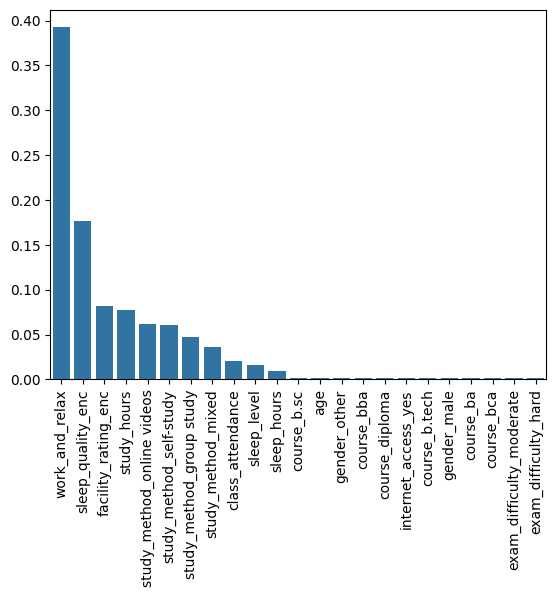

In [32]:
feat_imp = pd.Series(xgbst.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
sns.barplot(feat_imp);
plt.xticks(rotation=90);

We need pay attention that 'exam_score' ranges from 0 to 100. Therefore, if our prediction is out of this range, we need to limit it.

In [33]:
# we specify iteration_range, because we used early_stopping_rounds
# (if we don't specify it, the result will be the same)
xgb_pred = xgbst.predict(X_test_scaled, iteration_range=(0, xgbst.best_iteration + 1))
min(xgb_pred), max(xgb_pred)

(np.float32(14.223723), np.float32(104.414734))

In [34]:
xgb_pred = np.clip(xgb_pred, 0, 100)
min(xgb_pred), max(xgb_pred)

(np.float32(14.223723), np.float32(100.0))

In [35]:
result = pd.DataFrame({'id': idx_submission, 'exam_score': xgb_pred})
submission_xgb = result.to_csv('submission_xgb.csv', index=False)
print('✅ submission_xgb.csv created successfully!')

# score 8.71318

✅ submission_xgb.csv created successfully!


**5.2 LightGBM**

In [ ]:
import optuna
# from optuna.integration import LightGBMPruningCallback
from sklearn.model_selection import KFold
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import time

def objective(trial, X, y):
    params = {
        'boosting_type': 'gbdt',
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, step=0.05),
        'n_estimators': 10000, # we specify a large number of trees because we use early_stopping_rounds
        'objective': 'regression',
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 1.2, step=0.05),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 1.2, step=0.05),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
             }
    # we can determine 'num_leaves' through 'max_depth'
    # params['num_leaves'] = 2 ** params['max_depth']

    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    # for saving best scores
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        dtrain = lgb.Dataset(X_train, label=y_train)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        # training with early stopping
        model = lgb.train(params, dtrain, valid_sets=[dval], valid_names=['val'], 
                          num_boost_round=params['n_estimators'],
                          callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                          lgb.log_evaluation(period=0)] # disabling logs
                         )
        y_pred = model.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, y_pred))
        scores.append(score)
   
        # model = lgb.LGBMRegressor(**params)
        # model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        #           eval_metric='rmse',early_stopping_rounds=50,
        #           callbacks=[LightGBMPruningCallback(trial, "rmse")])
        # y_pred = model.predict(X_val)
        # score = np.sqrt(mean_squared_error(y_val, y_pred))
        # scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction='minimize', study_name='LGBM')

# measuring the execution time
start = time.time()
study.optimize(lambda trial: objective(trial, X_train_scaled, y_train), n_trials=100, 
               n_jobs=-1, show_progress_bar=True)
end = time.time()

lgb_optuna_score = study.best_value
lgb_optuna_params = study.best_params

print(f'Execution time: {end - start}')

In [37]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

# best hyperparameters that found using Optuna:
best_params = {'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.6, 'reg_alpha': 0.9500000000000001, 'reg_lambda': 0.8}

# we use early_stopping_rounds and validation sampling
lgbr = LGBMRegressor(**best_params, n_estimators=10000)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.1)
# we can see the metric in the validation dataset every 100 iterations
lgbr.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="rmse",
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=100)])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 567000, number of used features: 23
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 62.512460
[100]	valid_0's rmse: 8.94995	valid_0's l2: 80.1016
[200]	valid_0's rmse: 8.85174	valid_0's l2: 78.3534
[300]	valid_0's rmse: 8.83133	valid_0's l2: 77.9924
[400]	valid_0's rmse: 8.81808	valid_0's l2: 77.7585
[500]	valid_0's rmse: 8.80671	valid_0's l2: 77.5581
[600]	valid_0's rmse: 8.80164	valid_0's l2: 77.4689
[700]	valid_0's rmse: 8.79637	valid_0's l2: 77.3762
[800]	valid_0's rmse: 8.79215	valid_0's l2: 77.302
[900]	valid_0's rmse: 8.78886	valid_0's l2: 77.244
[1000]	valid_0's rmse: 8.78706

LGBMRegressor(colsample_bytree=0.6, learning_rate=0.05, max_depth=6,
              n_estimators=10000, reg_alpha=0.9500000000000001, reg_lambda=0.8)

In [38]:
lgbr.best_iteration_

1970

LGBM interprets feature importance very differently than XGBoost:

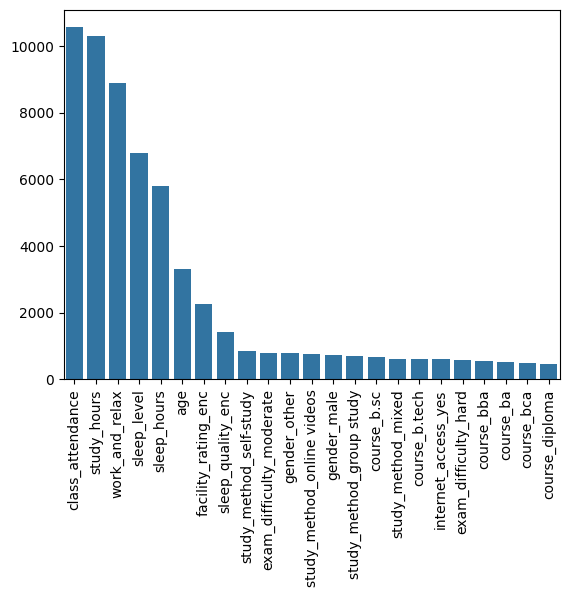

In [39]:
feat_imp = pd.Series(lgbr.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
sns.barplot(feat_imp);
plt.xticks(rotation=90);

In [41]:
# we specify start_iteration and num_iteration, because we used early_stopping_rounds
# (if we don't specify it, the result will be the same)
lgb_pred = lgbr.predict(X_test_scaled, start_iteration=0, num_iteration=lgbr.best_iteration_)
min(lgb_pred), max(lgb_pred)

(np.float64(14.0559365092318), np.float64(104.49793581001857))

In [42]:
lgb_pred = np.clip(lgb_pred, 0, 100)
min(lgb_pred), max(lgb_pred)

(np.float64(14.0559365092318), np.float64(100.0))

In [43]:
result = pd.DataFrame({'id': idx_submission, 'exam_score': lgb_pred})
submission_lgb = result.to_csv('submission_lgb.csv', index=False)
print('✅ submission_lgb.csv created successfully!')

# score 8.70858

✅ submission_lgb.csv created successfully!


**5.3 CatBoost**

In CatBoost, we can explicitly specify categorical features. CatBoost handles them in a special way.

In [32]:
X_train_catboost = X_train_num_scaled.astype('float32').join(df_train[other_cat_features])

X_train_catboost

,age,sleep_hours,study_hours,class_attendance,sleep_quality_enc,facility_rating_enc,gender,internet_access,exam_difficulty,study_method,course
0,0.200943,-1.245269,1.655874,1.538302,0.001130,-1.213656,female,no,easy,online videos,b.sc
1,-1.126352,-1.359895,0.401573,1.308814,-1.213871,0.017268,other,yes,moderate,self-study,diploma
2,-0.241488,-0.729454,0.287160,1.182595,-1.213871,1.248192,female,yes,moderate,coaching,b.sc
3,-0.683920,0.703367,-0.848492,-1.290141,0.001130,1.248192,male,yes,moderate,group study,b.sc
4,1.085807,1.448434,1.545699,0.855575,1.216131,1.248192,male,yes,easy,self-study,bca
...,...,...,...,...,...,...,...,...,...,...,...
629995,-1.126352,-1.703772,0.363435,-0.073853,1.216131,1.248192,female,yes,moderate,mixed,b.tech
629996,0.200943,-1.474521,1.304162,-1.009018,0.001130,-1.213656,female,yes,moderate,mixed,ba
629997,1.528239,-1.589146,-1.424793,-1.594213,-1.213871,-1.213656,male,yes,moderate,online videos,bca
629998,-0.241488,0.646054,-1.043417,0.178584,0.001130,1.248192,male,yes,moderate,group study,b.com


In [33]:
X_test_catboost = X_test_num_scaled.astype('float32').join(df_test[other_cat_features])

X_test_catboost

,age,sleep_hours,study_hours,class_attendance,sleep_quality_enc,facility_rating_enc,gender,internet_access,exam_difficulty,study_method,course
0,1.528239,-1.073331,1.206699,-0.389399,-1.213871,1.248192,other,yes,easy,group study,ba
1,-1.126352,1.276496,1.104999,-1.548315,-1.213871,-1.213656,male,no,easy,coaching,diploma
2,1.528239,-0.500202,1.100761,1.521091,1.216131,0.017268,female,yes,moderate,group study,b.tech
3,1.528239,-0.786767,-0.412029,-0.326290,0.001130,0.017268,male,yes,moderate,mixed,diploma
4,-0.241488,1.219183,-0.835779,-1.697482,0.001130,-1.213656,female,yes,moderate,coaching,b.tech
...,...,...,...,...,...,...,...,...,...,...,...
269995,0.200943,0.760680,-0.615429,0.591663,0.001130,0.017268,other,yes,hard,mixed,b.com
269996,-1.568784,0.989931,-1.488355,-1.467994,1.216131,-1.213656,female,yes,easy,mixed,b.com
269997,0.643375,-0.901392,1.109236,0.155635,1.216131,1.248192,male,yes,easy,coaching,bba
269998,0.643375,0.932619,0.032910,-1.158185,-1.213871,1.248192,other,yes,moderate,online videos,ba


Tuning hyperparameters for CatBoost is very time-consuming, especially if we specify categorical features.

In [ ]:
import optuna
# from catboost import Pool, cv
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import time

def objective(trial, X, y):
    params = {
        'iterations': 8000, # we specify a large number of trees because we use early_stopping_rounds
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, step=1),
        # 'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1, step=0.1),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
        # 'cat_features': other_cat_features # we can specify categorical features
             }

    # cv_dataset = Pool(data=X, label=y)
    # # cv returns a Pandas dataframe with columns 'iterations', 'test-RMSE-mean', 'test-RMSE-std',
    # # 'train-RMSE-mean', 'train-RMSE-std'. The rows are each boosting iteration
    # scores = cv(cv_dataset, params, fold_count=4,
    #             verbose=False, early_stopping_rounds=50)
    
    kf = KFold(n_splits=4, shuffle=True, random_state=42)
    # for saving best scores
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train, use_best_model=True,
                  eval_set=[(X_val, y_val)], early_stopping_rounds=50)
        y_pred = model.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, y_pred))
        scores.append(score) 

    return np.mean(scores)


study = optuna.create_study(direction='minimize', study_name='CatBoost')

# measuring the execution time
start = time.time()
study.optimize(lambda trial: objective(trial, X_train_scaled, y_train), n_trials=50, 
               n_jobs=-1, show_progress_bar=True)
end = time.time()

catboost_optuna_score = study.best_value
catboost_optuna_params = study.best_params

print(f'Execution time: {end - start}')

In [45]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

# best hyperparameters that found using Optuna:
best_params = {'learning_rate': 0.09481623620787497, 'depth': 6, 'l2_leaf_reg': 5.0}

# we use early_stopping_rounds and validation sampling
catbst = CatBoostRegressor(**best_params, n_estimators=10000)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.1)
# we can see the metric in the validation dataset every 100 iterations
catbst.fit(X_tr, y_tr, use_best_model=True, eval_set=[(X_val, y_val)],
           verbose_eval=100, early_stopping_rounds=50)

0:	learn: 17.7343186	test: 17.7706368	best: 17.7706368 (0)	total: 99ms	remaining: 16m 29s
100:	learn: 8.8600294	test: 8.8692603	best: 8.8692603 (100)	total: 3.53s	remaining: 5m 45s
200:	learn: 8.8188777	test: 8.8322431	best: 8.8322431 (200)	total: 6.98s	remaining: 5m 40s
300:	learn: 8.7937632	test: 8.8122038	best: 8.8122038 (300)	total: 10.4s	remaining: 5m 34s
400:	learn: 8.7747780	test: 8.7983405	best: 8.7983405 (400)	total: 13.8s	remaining: 5m 29s
500:	learn: 8.7590536	test: 8.7887839	best: 8.7887839 (500)	total: 17.2s	remaining: 5m 26s
600:	learn: 8.7449133	test: 8.7801572	best: 8.7801572 (600)	total: 20.6s	remaining: 5m 22s
700:	learn: 8.7322519	test: 8.7736038	best: 8.7735693 (699)	total: 24s	remaining: 5m 18s
800:	learn: 8.7209614	test: 8.7687880	best: 8.7687880 (800)	total: 27.5s	remaining: 5m 15s
900:	learn: 8.7101962	test: 8.7650276	best: 8.7650276 (900)	total: 30.9s	remaining: 5m 11s
1000:	learn: 8.7002576	test: 8.7619547	best: 8.7619547 (1000)	total: 34.3s	remaining: 5m 8s
1

In [46]:
catbst.get_best_iteration()

1832

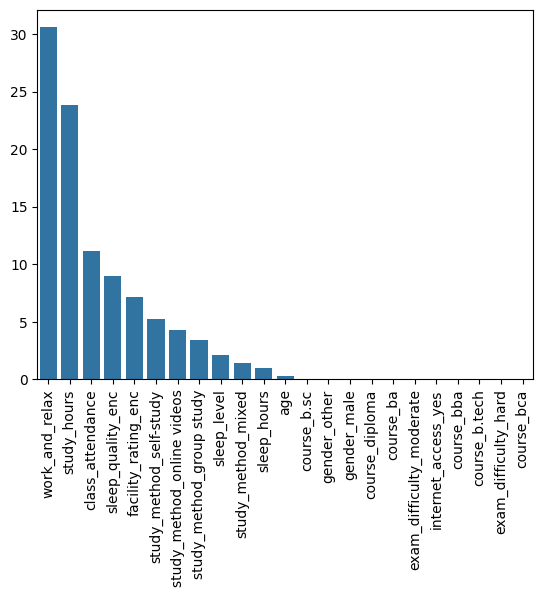

In [47]:
feat_imp = pd.Series(catbst.get_feature_importance(), index=X_train_scaled.columns).sort_values(ascending=False)
sns.barplot(feat_imp);
plt.xticks(rotation=90);

In [48]:
# we specify ntree_start and ntree_end, because we used early_stopping_rounds
# (if we don't specify it, the result will be the same)
catbst_pred = catbst.predict(X_test_scaled, ntree_start=0, ntree_end=catbst.get_best_iteration())
min(catbst_pred), max(catbst_pred)

(np.float64(14.359500604589961), np.float64(103.92127261896553))

In [49]:
catbst_pred = np.clip(catbst_pred, 0, 100)
min(catbst_pred), max(catbst_pred)

(np.float64(14.359500604589961), np.float64(100.0))

In [50]:
result = pd.DataFrame({'id': idx_submission, 'exam_score': catbst_pred})
submission_catbst = result.to_csv('submission_catbst.csv', index=False)
print('✅ submission_catbst.csv created successfully!')

# score 8.72456

✅ submission_catbst.csv created successfully!
